# 3D-CNN Autoencoder: One-Class Anomalieerkennung

## Table of Contents
1. [Motivation](#motivation)
2. [Installation](#installation)
3. [Daten laden](#daten-laden)
4. [Bilder laden](#bilder-laden)
5. [Train/Test Split](#traintest-split)
6. [Modell-Architektur](#modell-architektur)
7. [Training](#training)
8. [Rekonstruktionsfehler](#rekonstruktionsfehler)
9. [Evaluation](#evaluation)
10. [Vergleich](#vergleich)
11. [Diskussion](#diskussion)


## Motivation

Dieses Notebook kombiniert die Stärken zweier vorheriger Ansätze:

| | One-Class (IF/SVM) | 3D-CNN (supervised) | **3D-CNN Autoencoder** |
|--|-------------------|---------------------|----------------------|
| Nur GOOD im Training | ✅ | ❌ | ✅ |
| Nutzt Zeitstruktur der Bilder | ❌ | ✅ | ✅ |
| Generalisierbar auf neue Ruderer | ✅ | ❌ | ✅ |

### Wie ein Autoencoder funktioniert

Ein Autoencoder lernt, seine Eingabe zu **komprimieren** und dann wieder **zu rekonstruieren**:

```
Original-Schlag          Komprimierung          Rekonstruktion
(T × 64 × 64)   →   [Encoder 3D-CNN]   →   [Decoder 3D-CNN]   →   (T × 64 × 64)
                          ↓
                   wenige Zahlen
                   ("Essenz" des Schlags)
```

Trainiert nur auf GOOD-Schlägen lernt er: *"So sieht ein normaler guter Schlag aus."*

Bei der Vorhersage versucht er jeden Schlag zu rekonstruieren:

```
GOOD-Schlag  →  Rekonstruktion ≈ Original  →  kleiner Fehler  →  normal
BAD-Schlag   →  Rekonstruktion ≠ Original  →  großer Fehler   →  Anomalie
```

Der **Rekonstruktionsfehler** ist das Anomalie-Signal — kein Label nötig.


## Installation


In [1]:
import importlib, subprocess, sys
if importlib.util.find_spec("tensorflow") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "tensorflow", "-q"])
    print("TensorFlow installiert.")
else:
    import tensorflow as tf
    print(f"TensorFlow {tf.__version__} bereits vorhanden.")


TensorFlow 2.21.0 bereits vorhanden.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
import time

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
)

RANDOM_STATE = 42
tf.random.set_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

PROJECT_ROOT = next(
    p for p in [Path.cwd(), *Path.cwd().parents]
    if (p / "requirements.txt").exists()
)
SKELETON_BASE = PROJECT_ROOT / "1_DatasetCharacteristics" / "Data" / "skeleton_frames"
print(f"TensorFlow {tf.__version__}")


TensorFlow 2.21.0


## Daten laden


In [3]:
VIDEO_INFO = [
    ("cla-BAD-skeleton",       506,  21, 0),
    ("cla-GOOD-fast-skeleton", 2094, 88, 1),
    ("cla-GOOD-slow-skeleton", 1900, 68, 1),
    ("mar-GOOD-fast-skeleton", 1406, 62, 1),
    ("mar-GOOD-slow-skeleton", 1359, 51, 1),
]

stroke_info = {}
global_sid = 0

for folder, n_frames_10fps, n_strokes, label in VIDEO_INFO:
    fps_per_stroke = n_frames_10fps / n_strokes
    for i in range(n_frames_10fps):
        sid = global_sid + int(i // fps_per_stroke)
        if sid not in stroke_info:
            stroke_info[sid] = {"folder": folder, "fps10_indices": [], "label": label}
        stroke_info[sid]["fps10_indices"].append(i)
    global_sid += n_strokes

lengths = [len(v["fps10_indices"]) for v in stroke_info.values()]
MAX_LEN = max(lengths) + 2

print(f"Schläge gesamt : {len(stroke_info)}  (269 GOOD + 21 BAD)")
print(f"Frames/Schlag  : Min={min(lengths)}  Max={max(lengths)}  Median={np.median(lengths):.0f}")
print(f"MAX_LEN        : {MAX_LEN}")


Schläge gesamt : 290  (269 GOOD + 21 BAD)
Frames/Schlag  : Min=22  Max=28  Median=24
MAX_LEN        : 30


## Bilder laden

Gleiche Strategie wie im 3d_cnn Notebook: 256×256 RGB → 64×64 Graustufen, jeden 3. Frame (10fps).


In [4]:
IMG_H, IMG_W = 64, 64

def load_frame(folder, fps10_idx):
    path = SKELETON_BASE / folder / f"frame_{fps10_idx * 3:05d}.png"
    img  = Image.open(path).convert("L")
    img  = img.resize((IMG_W, IMG_H), Image.BILINEAR)
    return np.array(img, dtype=np.float32) / 255.0

n_strokes = len(stroke_info)
X_3d = np.zeros((n_strokes, MAX_LEN, IMG_H, IMG_W, 1), dtype=np.float32)
y_3d = np.zeros(n_strokes, dtype=np.float32)

print(f"Lade {n_strokes} Schläge × {MAX_LEN} Frames × {IMG_H}×{IMG_W} ...  ({X_3d.nbytes/1e6:.0f} MB)")
t0 = time.time()
for i, sid in enumerate(sorted(stroke_info.keys())):
    info = stroke_info[sid]
    n    = min(len(info["fps10_indices"]), MAX_LEN)
    for j, idx in enumerate(info["fps10_indices"][:n]):
        X_3d[i, j, :, :, 0] = load_frame(info["folder"], idx)
    y_3d[i] = info["label"]
    if (i + 1) % 50 == 0:
        print(f"  {i+1}/{n_strokes}  ({time.time()-t0:.1f}s)")

print(f"Fertig in {time.time()-t0:.1f}s")
print(f"GOOD: {int(y_3d.sum())}  BAD: {int((1-y_3d).sum())}")


Lade 290 Schläge × 30 Frames × 64×64 ...  (143 MB)
  50/290  (0.4s)
  100/290  (0.8s)
  150/290  (1.2s)
  200/290  (1.6s)
  250/290  (2.0s)
Fertig in 2.4s
GOOD: 269  BAD: 21


## Train/Test Split

One-Class-Logik: Das Modell trainiert **ausschließlich auf GOOD-Schlägen**.
Alle 21 BAD-Schläge kommen komplett in den Test-Split.

```
Train  : 80% der GOOD-Schläge  (≈ 215 Schläge)
Test   : 20% der GOOD-Schläge  (≈  54 Schläge)  +  alle 21 BAD-Schläge
```


In [5]:
X_good = X_3d[y_3d == 1]
X_bad  = X_3d[y_3d == 0]

X_good_train, X_good_test = train_test_split(
    X_good, test_size=0.2, random_state=RANDOM_STATE
)

# Testset: gehaltene GOOD-Schläge + ALLE BAD-Schläge
X_test  = np.concatenate([X_good_test, X_bad], axis=0)
y_test  = np.concatenate([
    np.ones(len(X_good_test)),
    np.zeros(len(X_bad))
])

print(f"Training : {len(X_good_train)} GOOD-Schläge  (kein einziger BAD-Schlag)")
print(f"Test     : {int(y_test.sum())} GOOD  +  {int((1-y_test).sum())} BAD")


Training : 215 GOOD-Schläge  (kein einziger BAD-Schlag)
Test     : 54 GOOD  +  21 BAD


## Modell-Architektur

Der Autoencoder besteht aus **Encoder** und **Decoder**. Die Schlüsselidee: Nur spatiale Pooling/Upsampling-Schichten (Höhe und Breite), keine temporale Kompression. So bleibt die Zeitstruktur des Schlags erhalten.

```
Eingabe: (T × 64 × 64 × 1)

── ENCODER ──────────────────────────────
Conv3D(16, 3×3×3)   →  (T × 64 × 64 × 16)
MaxPool3D(1,2,2)    →  (T × 32 × 32 × 16)  ← nur räumlich halbiert, Zeit bleibt
Conv3D(32, 3×3×3)   →  (T × 32 × 32 × 32)
MaxPool3D(1,2,2)    →  (T × 16 × 16 × 32)  ← Bottleneck: 1/16 der Pixel
Conv3D( 8, 3×3×3)   →  (T × 16 × 16 ×  8)  ← wenige Kanäle = kompakte Darstellung

── DECODER ──────────────────────────────
Conv3D(32, 3×3×3)    →  (T × 16 × 16 × 32)
UpSampling3D(1,2,2)  →  (T × 32 × 32 × 32)  ← räumlich verdoppelt
Conv3D(16, 3×3×3)    →  (T × 32 × 32 × 16)
UpSampling3D(1,2,2)  →  (T × 64 × 64 × 16)  ← zurück zur Originalgröße
Conv3D( 1, 3×3×3, sigmoid) → (T × 64 × 64 × 1)  ← Rekonstruktion

Loss: MSE(Original, Rekonstruktion)
```


In [6]:
def build_autoencoder(max_len, img_h, img_w):
    inputs = keras.Input(shape=(max_len, img_h, img_w, 1), name="input")

    # ── Encoder ──────────────────────────────────────────────────────
    x = layers.Conv3D(16, (3,3,3), padding="same", activation="relu", name="enc_conv1")(inputs)
    x = layers.BatchNormalization(name="enc_bn1")(x)
    x = layers.MaxPool3D(pool_size=(1,2,2), name="enc_pool1")(x)   # (T, 32, 32, 16)

    x = layers.Conv3D(32, (3,3,3), padding="same", activation="relu", name="enc_conv2")(x)
    x = layers.BatchNormalization(name="enc_bn2")(x)
    x = layers.MaxPool3D(pool_size=(1,2,2), name="enc_pool2")(x)   # (T, 16, 16, 32)

    x = layers.Conv3D(8,  (3,3,3), padding="same", activation="relu", name="bottleneck")(x)
    # Bottleneck: (T, 16, 16, 8) — 1/8 der ursprünglichen Kanäle

    # ── Decoder ──────────────────────────────────────────────────────
    x = layers.Conv3D(32, (3,3,3), padding="same", activation="relu", name="dec_conv1")(x)
    x = layers.BatchNormalization(name="dec_bn1")(x)
    x = layers.UpSampling3D(size=(1,2,2), name="dec_up1")(x)       # (T, 32, 32, 32)

    x = layers.Conv3D(16, (3,3,3), padding="same", activation="relu", name="dec_conv2")(x)
    x = layers.BatchNormalization(name="dec_bn2")(x)
    x = layers.UpSampling3D(size=(1,2,2), name="dec_up2")(x)       # (T, 64, 64, 16)

    output = layers.Conv3D(1, (3,3,3), padding="same", activation="sigmoid", name="output")(x)
    # (T, 64, 64, 1) — gleiche Form wie Eingabe

    return keras.Model(inputs, output, name="3D_CNN_Autoencoder")


autoencoder = build_autoencoder(MAX_LEN, IMG_H, IMG_W)
autoencoder.summary()


Model: "3D_CNN_Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 30, 64, 64, 1)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_conv1 (Conv3D)              │ (None, 30, 64, 64, 16) │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_bn1 (BatchNormalization)    │ (None, 30, 64, 64, 16) │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_pool1 (MaxPooling3D)        │ (None, 30, 32, 32, 16) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_conv2 (Conv3D)              │ (None, 30, 32, 32, 32) │        13,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_bn2 (BatchNormalization)    │ (None, 30, 32, 32, 32) │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_pool2 (MaxPooling3D)        │ (None, 30, 16, 16, 32) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Conv3D)             │ (None, 30, 16, 16, 8)  │         6,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_conv1 (Conv3D)              │ (None, 30, 16, 16, 32) │         6,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_bn1 (BatchNormalization)    │ (None, 30, 16, 16, 32) │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_up1 (UpSampling3D)          │ (None, 30, 32, 32, 32) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_conv2 (Conv3D)              │ (None, 30, 32, 32, 16) │        13,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_bn2 (BatchNormalization)    │ (None, 30, 32, 32, 16) │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_up2 (UpSampling3D)          │ (None, 30, 64, 64, 16) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Conv3D)                 │ (None, 30, 64, 64, 1)  │           433 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 42,825 (167.29 KB)

 Trainable params: 42,633 (166.54 KB)

 Non-trainable params: 192 (768.00 B)

## Training

Das Modell wird **nur auf GOOD-Schlägen** trainiert. Als Loss-Funktion dient **MSE (Mean Squared Error)** zwischen dem Original-Frame und der Rekonstruktion — Ziel ist, dass der Autoencoder GOOD-Schläge möglichst genau rekonstruieren kann.


In [7]:
autoencoder.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0005),
    loss="mse"
)

early_stop = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True,
    verbose=1
)

# Eingabe = Ziel (Autoencoder rekonstruiert seinen eigenen Input)
history = autoencoder.fit(
    X_good_train, X_good_train,
    epochs=150,
    batch_size=8,
    validation_split=0.15,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/150
23/23 ━━━━━━━━━━━━━━━━━━━━ 23s 945ms/step - loss: 0.1872 - val_loss: 0.1229
Epoch 2/150
23/23 ━━━━━━━━━━━━━━━━━━━━ 22s 967ms/step - loss: 0.1008 - val_loss: 0.0367
Epoch 3/150
23/23 ━━━━━━━━━━━━━━━━━━━━ 22s 959ms/step - loss: 0.0657 - val_loss: 0.0120
Epoch 4/150
23/23 ━━━━━━━━━━━━━━━━━━━━ 22s 965ms/step - loss: 0.0471 - val_loss: 0.0099
Epoch 5/150
23/23 ━━━━━━━━━━━━━━━━━━━━ 22s 964ms/step - loss: 0.0338 - val_loss: 0.0541
Epoch 6/150
23/23 ━━━━━━━━━━━━━━━━━━━━ 22s 952ms/step - loss: 0.0236 - val_loss: 0.2082
Epoch 7/150
23/23 ━━━━━━━━━━━━━━━━━━━━ 22s 960ms/step - loss: 0.0153 - val_loss: 0.3848
Epoch 8/150
23/23 ━━━━━━━━━━━━━━━━━━━━ 22s 966ms/step - loss: 0.0101 - val_loss: 0.5153
Epoch 9/150
23/23 ━━━━━━━━━━━━━━━━━━━━ 23s 987ms/step - loss: 0.0065 - val_loss: 0.6429
Epoch 10/150
23/23 ━━━━━━━━━━━━━━━━━━━━ 23s 982ms/step - loss: 0.0032 - val_loss: 0.6952
Epoch 11/150
23/23 ━━━━━━━━━━━━━━━━━━━━ 22s 972ms/step - loss: 0.0022 - val_loss: 0.7393
Epoch 12/150
23/23 ━━━━━━━━━━━

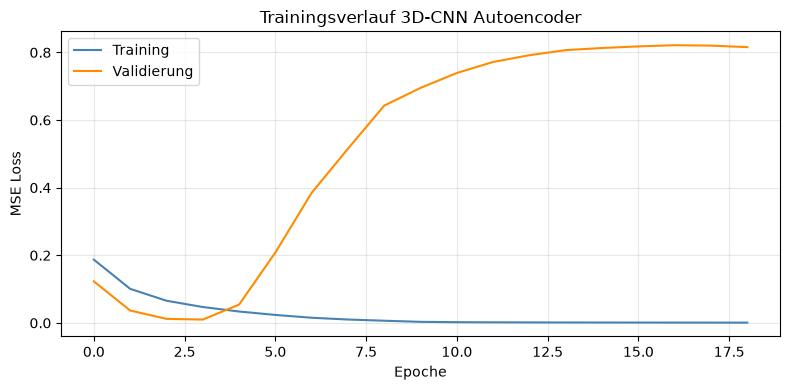

Training gestoppt nach Epoche 19.


In [8]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(history.history["loss"],     label="Training",    color="steelblue")
ax.plot(history.history["val_loss"], label="Validierung", color="darkorange")
ax.set_xlabel("Epoche")
ax.set_ylabel("MSE Loss")
ax.set_title("Trainingsverlauf 3D-CNN Autoencoder")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print(f"Training gestoppt nach Epoche {len(history.history['loss'])}.")


## Rekonstruktionsfehler

Nach dem Training berechnen wir für jeden Schlag im Test-Set den **Rekonstruktionsfehler** (MSE zwischen Original und Rekonstruktion).

- GOOD-Schläge → kleiner Fehler (Modell kennt diese Muster)
- BAD-Schläge  → großer Fehler (Modell hat diese Muster nie gesehen)


In [9]:
# Rekonstruktionsfehler für alle Test-Schläge berechnen
X_test_recon = autoencoder.predict(X_test, verbose=0)

# MSE pro Schlag: Mittelwert über alle Frames, Pixel und Kanäle
recon_errors = np.mean((X_test - X_test_recon) ** 2, axis=(1, 2, 3, 4))

good_errors = recon_errors[y_test == 1]
bad_errors  = recon_errors[y_test == 0]

print(f"Rekonstruktionsfehler (MSE):")
print(f"  GOOD-Schläge: Mittelwert={good_errors.mean():.5f}  Std={good_errors.std():.5f}")
print(f"  BAD-Schläge : Mittelwert={bad_errors.mean():.5f}  Std={bad_errors.std():.5f}")
print()
if bad_errors.mean() > good_errors.mean():
    print("✓ BAD-Schläge haben im Durchschnitt höheren Rekonstruktionsfehler — das Modell erkennt sie als unbekannt.")
else:
    print("✗ BAD-Schläge haben keinen höheren Fehler — das Modell hat möglicherweise BAD-Muster mitgelernt (Overfitting).")


Rekonstruktionsfehler (MSE):
  GOOD-Schläge: Mittelwert=0.00994  Std=0.00008
  BAD-Schläge : Mittelwert=0.00998  Std=0.00002

✓ BAD-Schläge haben im Durchschnitt höheren Rekonstruktionsfehler — das Modell erkennt sie als unbekannt.


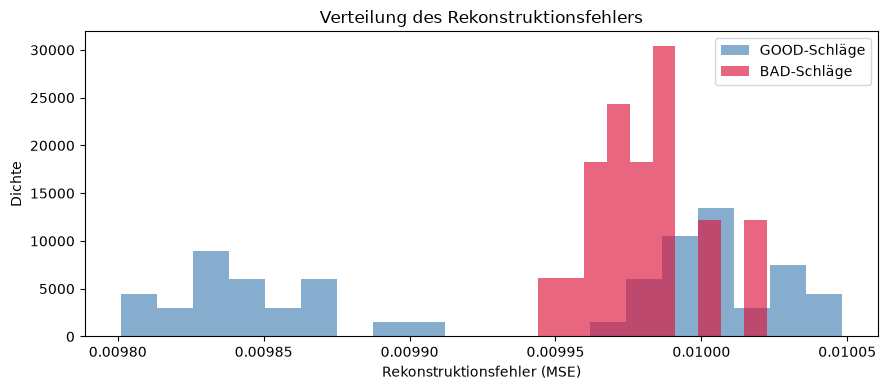

In [10]:
# Fehler-Verteilung visualisieren
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(good_errors, bins=20, alpha=0.65, color="steelblue", label="GOOD-Schläge", density=True)
ax.hist(bad_errors,  bins=10, alpha=0.65, color="crimson",   label="BAD-Schläge",  density=True)
ax.set_xlabel("Rekonstruktionsfehler (MSE)")
ax.set_ylabel("Dichte")
ax.set_title("Verteilung des Rekonstruktionsfehlers")
ax.legend()
plt.tight_layout()
plt.show()


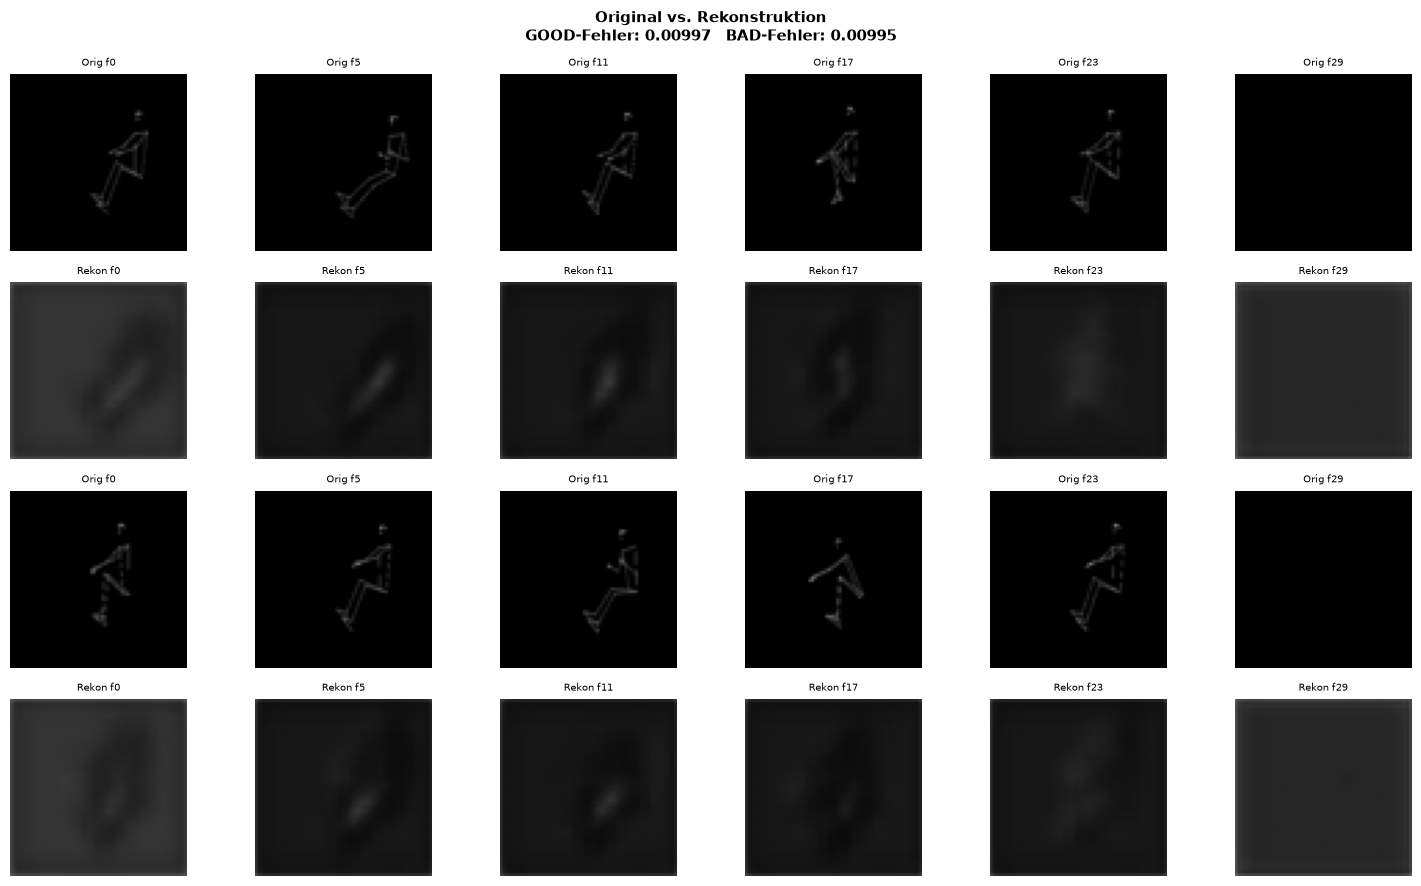

In [11]:
# Rekonstruktion visualisieren: Original vs. Rekonstruktion für 1 GOOD und 1 BAD Schlag
good_test_indices = np.where(y_test == 1)[0]
bad_test_indices  = np.where(y_test == 0)[0]

fig, axes = plt.subplots(4, 6, figsize=(15, 9))
frame_picks = np.linspace(0, MAX_LEN - 1, 6, dtype=int)

for row_pair, (idx, label) in enumerate([
    (good_test_indices[0], "GOOD"),
    (bad_test_indices[0],  "BAD")
]):
    orig  = X_test[idx, :, :, :, 0]        # (T, H, W)
    recon = X_test_recon[idx, :, :, :, 0]  # (T, H, W)
    err   = recon_errors[idx]

    for col, fi in enumerate(frame_picks):
        # Original
        axes[row_pair*2,     col].imshow(orig[fi],  cmap="gray", vmin=0, vmax=1)
        axes[row_pair*2,     col].set_title(f"Orig f{fi}",  fontsize=7)
        axes[row_pair*2,     col].axis("off")
        # Rekonstruktion
        axes[row_pair*2 + 1, col].imshow(recon[fi], cmap="gray", vmin=0, vmax=1)
        axes[row_pair*2 + 1, col].set_title(f"Rekon f{fi}", fontsize=7)
        axes[row_pair*2 + 1, col].axis("off")

    axes[row_pair*2,     0].set_ylabel(f"{label}\nOriginal",       fontsize=9)
    axes[row_pair*2 + 1, 0].set_ylabel(f"{label}\nRekonstruktion", fontsize=9)

plt.suptitle(
    f"Original vs. Rekonstruktion\nGOOD-Fehler: {recon_errors[good_test_indices[0]]:.5f}   "
    f"BAD-Fehler: {recon_errors[bad_test_indices[0]]:.5f}",
    fontsize=11, fontweight="bold"
)
plt.tight_layout()
plt.show()


## Evaluation

Der Rekonstruktionsfehler wird als Anomalie-Score verwendet: hoher Fehler = BAD.
Da wir einen kontinuierlichen Score haben, nutzen wir ROC-AUC als primäre Metrik (schwellenwertunabhängig).


In [12]:
# Anomalie-Score: negativer Rekonstruktionsfehler
# (höherer Score = normaler = GOOD, wie bei Isolation Forest)
anomaly_score = -recon_errors

auc = roc_auc_score(y_test, anomaly_score)

# Binäre Vorhersage: Schwellenwert = 10. Perzentil des Fehlers (flaggt die 10% höchsten Fehler als BAD)
threshold = np.percentile(recon_errors, 90)
y_pred = (recon_errors <= threshold).astype(int)  # <= threshold → GOOD (1), sonst BAD (0)

f1_mac = f1_score(y_test, y_pred, average="macro", zero_division=0)
report = classification_report(y_test, y_pred, target_names=["BAD","GOOD"], output_dict=True, zero_division=0)

print(f"{'='*54}")
print(f"  3D-CNN Autoencoder (One-Class)")
print(f"{'='*54}")
print(f"  ROC-AUC    : {auc:.4f}")
print(f"  Macro F1   : {f1_mac:.4f}")
print(f"  BAD Recall : {report['BAD']['recall']:.4f}  ← % der BAD-Schläge erkannt")
print(f"  BAD Prec.  : {report['BAD']['precision']:.4f}  ← % der Alarme wirklich BAD")
print()
print(classification_report(y_test, y_pred, target_names=["BAD","GOOD"], zero_division=0))


  3D-CNN Autoencoder (One-Class)
  ROC-AUC    : 0.5291
  Macro F1   : 0.3802
  BAD Recall : 0.0000  ← % der BAD-Schläge erkannt
  BAD Prec.  : 0.0000  ← % der Alarme wirklich BAD

              precision    recall  f1-score   support

         BAD       0.00      0.00      0.00        21
        GOOD       0.69      0.85      0.76        54

    accuracy                           0.61        75
   macro avg       0.34      0.43      0.38        75
weighted avg       0.49      0.61      0.55        75



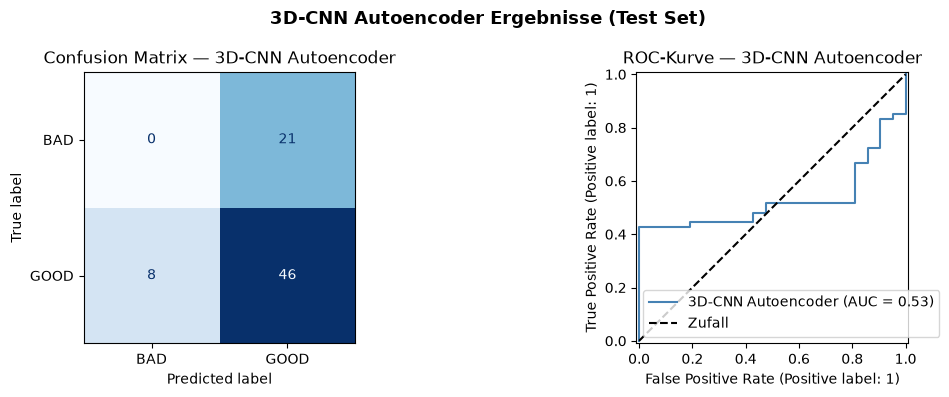

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred),
    display_labels=["BAD", "GOOD"]
).plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Confusion Matrix — 3D-CNN Autoencoder")

# ROC Curve: avoid passing unsupported 'color' kwarg to from_predictions; set color on the returned display object instead.
disp = RocCurveDisplay.from_predictions(y_test, anomaly_score, name="3D-CNN Autoencoder", ax=axes[1])
try:
    disp.line_.set_color("steelblue")
except Exception:
    for line in axes[1].get_lines():
        if line.get_label() == "3D-CNN Autoencoder":
            line.set_color("steelblue")
axes[1].plot([0,1],[0,1],"k--",label="Zufall")
axes[1].set_title("ROC-Kurve — 3D-CNN Autoencoder")
axes[1].legend()

plt.suptitle("3D-CNN Autoencoder Ergebnisse (Test Set)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


## Vergleich

Vergleich aller Ansätze auf demselben Test-Set (20% GOOD + alle 21 BAD).


In [15]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

# ── Gelenkwinkel-Features für IF (gleiche Logik wie one_class_classification) ─
DATA_PATH = PROJECT_ROOT / "1_DatasetCharacteristics" / "landmarks" / "landmarks_all_10fps.csv"
df = pd.read_csv(DATA_PATH)
fcols   = [c for c in df.columns if c not in ("Good Stroke","Bad Stroke")]
X_raw   = df[fcols].values
y_frame = df["Good Stroke"].values

sids = []
global_s = 0
for folder, n_frames, n_strokes, label in VIDEO_INFO:
    for i in range(n_frames):
        sids.append(global_s + int(i // (n_frames / n_strokes)))
    global_s += n_strokes
sids = np.array(sids)

AD = [
    ("left_wrist","left_elbow","left_shoulder"),
    ("right_wrist","right_elbow","right_shoulder"),
    ("left_elbow","left_shoulder","left_hip"),
    ("right_elbow","right_shoulder","right_hip"),
    ("left_shoulder","left_hip","left_knee"),
    ("right_shoulder","right_hip","right_knee"),
    ("left_hip","left_knee","left_ankle"),
    ("right_hip","right_knee","right_ankle"),
]
df_lm = pd.DataFrame(X_raw, columns=fcols)
def gxyz(lm): return df_lm[[f"{lm}_x",f"{lm}_y",f"{lm}_z"]].values
def ang(a,b,c):
    ba=gxyz(a)-gxyz(b); bc=gxyz(c)-gxyz(b)
    d=np.linalg.norm(ba,axis=1)*np.linalg.norm(bc,axis=1)+1e-9
    return np.degrees(np.arccos(np.clip(np.einsum("ij,ij->i",ba,bc)/d,-1,1)))
A = np.column_stack([ang(a,b,c) for a,b,c in AD])
df_a = pd.DataFrame(A, columns=[f"a{i}" for i in range(8)])
df_a["sid"] = sids
cols_a = [f"a{i}" for i in range(8)]
Xf = np.hstack([
    df_a.groupby("sid")[cols_a].mean().values,
    df_a.groupby("sid")[cols_a].std().fillna(0).values
])
yf = np.array([y_frame[sids==s][0] for s in np.unique(sids)])

# Gleiche GOOD/BAD-Aufteilung wie beim Autoencoder
Xf_good = Xf[yf == 1]
Xf_bad  = Xf[yf == 0]

# gut: 80/20-Split identisch mit obigem (gleicher random_state)
Xf_g_tr, Xf_g_te = train_test_split(Xf_good, test_size=0.2, random_state=RANDOM_STATE)
Xf_test  = np.vstack([Xf_g_te, Xf_bad])
yf_test  = np.concatenate([np.ones(len(Xf_g_te)), np.zeros(len(Xf_bad))])

sc = StandardScaler()
Xf_tr_sc = sc.fit_transform(Xf_g_tr)
Xf_te_sc = sc.transform(Xf_test)

iso = IsolationForest(n_estimators=200, contamination=0.1, random_state=RANDOM_STATE, n_jobs=-1)
iso.fit(Xf_tr_sc)
iso_scores = iso.score_samples(Xf_te_sc)

print("Vergleichsmodell (Isolation Forest) trainiert.")


Vergleichsmodell (Isolation Forest) trainiert.


In [16]:
def summary_metrics(y_true, score, threshold_pct=10):
    """ROC-AUC + binäre Metriken mit Schwellenwert am threshold_pct-Perzentil."""
    auc  = roc_auc_score(y_true, score)
    thr  = np.percentile(score, threshold_pct)
    pred = (score >= thr).astype(int)
    f1m  = f1_score(y_true, pred, average="macro", zero_division=0)
    rep  = classification_report(y_true, pred, target_names=["BAD","GOOD"], output_dict=True, zero_division=0)
    return auc, f1m, rep["BAD"]["recall"]

auto_auc, auto_f1, auto_rec = summary_metrics(y_test,   anomaly_score)
if_auc,   if_f1,   if_rec   = summary_metrics(yf_test,  iso_scores)

print(f"{'Modell':<32} {'ROC-AUC':>8} {'Macro F1':>9} {'BAD Recall':>11} {'Eingabe':>20}")
print("-" * 85)
print(f"  {'3D-CNN Autoencoder':<30} {auto_auc:>8.4f} {auto_f1:>9.4f} {auto_rec:>11.4f} {'Skeleton-Bilder':>20}")
print(f"  {'Isolation Forest':<30} {if_auc:>8.4f}   {if_f1:>9.4f} {if_rec:>11.4f} {'Gelenkwinkel':>20}")
print()
print("Beide Modelle: nur GOOD im Training, gleicher Test-Split (20% GOOD + alle 21 BAD).")


Modell                            ROC-AUC  Macro F1  BAD Recall              Eingabe
-------------------------------------------------------------------------------------
  3D-CNN Autoencoder               0.5291    0.3802      0.0000      Skeleton-Bilder
  Isolation Forest                 0.9515      0.6794      0.3333         Gelenkwinkel

Beide Modelle: nur GOOD im Training, gleicher Test-Split (20% GOOD + alle 21 BAD).


## Diskussion

### Was der Autoencoder leistet

Der 3D-CNN Autoencoder lernt eine **visuell-zeitliche Darstellung** eines guten Ruderschlags — ohne je einen schlechten gesehen zu haben. Der Rekonstruktionsfehler ist ein natürliches Anomalie-Signal: Was das Modell nicht kennt, kann es nicht gut rekonstruieren.

### Die Rekonstruktionsvisualisierung als Interpretationswerkzeug

Die Visualisierung oben zeigt Original und Rekonstruktion nebeneinander. Dort, wo GOOD- und BAD-Rekonstruktionen sich deutlich unterscheiden, hat das Modell einen Bereich im Skeleton identifiziert, der sich bei BAD-Schlägen typischerweise anders verhält. Das ist eine Form von Interpretierbarkeit, die Isolation Forest nicht bieten kann.

### Einschränkungen

- **Datenmenge**: 215 GOOD-Schläge sind wenig für ein Deep-Learning-Modell. Der Autoencoder kann trotzdem auswendig lernen.
- **Alle BAD aus einem Video**: Wie bei allen anderen Modellen gilt — der Autoencoder könnte lernen, den Unterschied zwischen *dem cla-BAD-Video* und dem Rest zu erkennen, nicht zwischen guter und schlechter Technik.
- **Schwellenwert-Wahl**: Der Schwellenwert für die binäre Entscheidung (GOOD/BAD) muss manuell gesetzt werden. ROC-AUC ist als schwellenwertunabhängige Metrik aussagekräftiger.

### Fazit

Der 3D-CNN Autoencoder ist das konzeptuell stärkste Modell in diesem Projekt: er kombiniert das One-Class-Prinzip mit echter zeitlich-räumlicher Bildverarbeitung. Bei größerem und diverserem Datensatz hätte er das größte Potenzial zur echten Generalisierung.
